Лабораторна робота №2

Виконав: Верещака Олександр ПР-2-2
Варіант №1

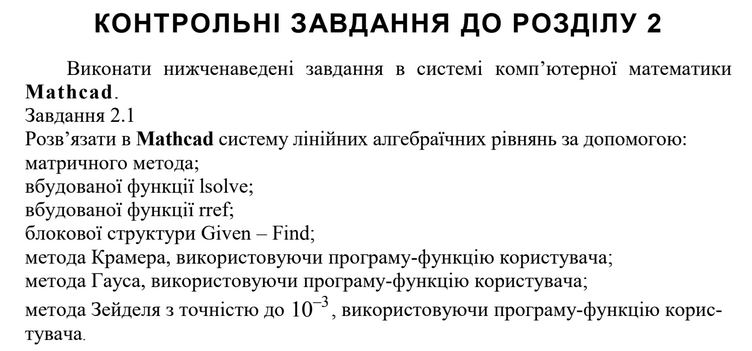

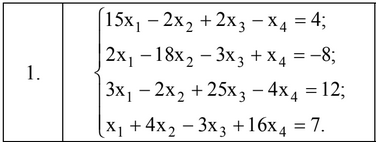

In [ ]:
# Task 2.1: Розв'язання системи лінійних рівнянь різними методами
import numpy as np
import sympy as sp
from scipy.optimize import root

A = np.array([[15, -2, 2, -1], [2, -18, -3, 1], [3, -2, 25, -4], [1, 4, -3, 16]])
# Вектор вільних членів B
B = np.array([4, -8, 12, 7])

# Розв'язок системи рівнянь за допомогою оберненої матриці
if np.linalg.det(A) == 0:
    print("Система не має розв'язку або має безліч розв'язків.")
else:
    X = np.linalg.inv(A) @ B
    print(
        "Розв'язок системи рівнянь за допомогою оберненої матриці:", *X, sep="\n\t->| "
    )
    print("Перевірка розв'язку:")
    print("A @ X =", A @ X)
    print("B =", B)

# Аналог вбудованої функції lsolve
print(
    "\nРозв'язок системи за допомогою структури lsolve: ",
    *np.linalg.solve(A, B),
    sep="\n\t->| ",
)

# Аналог вбудованої функції rref
AB = np.column_stack((A, B))
rref_matrix, _ = sp.Matrix(AB).rref()
print(
    "\nРозв'язок системи за допомогою метода Гауса (rref): ",
    *rref_matrix[:, -1],
    sep="\n\t->| ",
)


# Розв'язок системи за допомогою методу Given-Find
def system(array, A, B):
    return A @ array - B


result = root(system, [1, 1, 1, 1], args=(A, B), method="hybr")
print("\nРозв'язок системи за допомогою методу Given-Find: ", *result.x, sep="\n\t->| ")

# Розв'язок системи за допомогою метода Крамера
Xj = np.zeros(len(B))
for j in range(len(B)):
    Aj = np.copy(A)
    Aj[:, j] = B
    Xj[j] = np.linalg.det(Aj) / np.linalg.det(A)
print("\nРозв'язок системи за допомогою метода Крамера: ", *Xj, sep="\n\t->| ")

# Розв'язок системи за допомогою метода Гауса
n = len(B)
Ar = np.column_stack((A, B)).astype(float)

for i in range(n):
    for k in range(i + 1, n):
        factor = Ar[k][i] / Ar[i][i]
        Ar[k] = Ar[k] - factor * Ar[i]

X_gauss = np.zeros(n)
for i in range(n - 1, -1, -1):
    X_gauss[i] = (Ar[i][-1] - np.dot(Ar[i][i + 1 : n], X_gauss[i + 1 : n])) / Ar[i][i]
print("\nРозв'язок системи за допомогою метода Гауса: ", *X_gauss, sep="\n\t->| ")

# Розв'язок системи за допомогою метода Зейделя
C = np.zeros((n, n))
D = np.zeros(n)

for i in range(n):
    D[i] = B[i] / A[i][i]
    for j in range(n):
        if i != j:
            C[i][j] = -A[i][j] / A[i][i]

epsilon = 1e-3  # наша задана точність згідно з умовою
error = 1.0
X = np.copy(D)

while error > epsilon:
    X_old = np.copy(X)

    # Оновлюємо елементи за методом Зейделя
    for i in range(n):
        X[i] = C[i] @ X + D[i]

    error = np.max(np.abs(X - X_old))

print("\nРозв'язок системи за допомогою метода Зейделя: ", *X, sep="\n\t->| ")

Розв'язок системи рівнянь за допомогою оберненої матриці:
	->| 0.2761383285302593
	->| 0.4073775216138328
	->| 0.5468011527377521
	->| 0.4209221902017291
Перевірка розв'язку:
A @ X = [ 4. -8. 12.  7.]
B = [ 4 -8 12  7]

Розв'язок системи за допомогою структури lsolve: 
	->| 0.2761383285302594
	->| 0.40737752161383284
	->| 0.5468011527377521
	->| 0.4209221902017291

Розв'язок системи за допомогою метода Гауса (rref): 
	->| 4791/17350
	->| 3534/8675
	->| 9487/17350
	->| 7303/17350

Розв'язок системи за допомогою методу Given-Find: 
	->| 0.2761383285302594
	->| 0.40737752161383284
	->| 0.5468011527377522
	->| 0.4209221902017291

Розв'язок системи за допомогою метода Крамера: 
	->| 0.2761383285302594
	->| 0.40737752161383317
	->| 0.5468011527377526
	->| 0.42092219020172944

Розв'язок системи за допомогою метода Гауса: 
	->| 0.2761383285302594
	->| 0.40737752161383284
	->| 0.5468011527377521
	->| 0.4209221902017291

Розв'язок системи за допомогою метода Зейделя: 
	->| 0.2761559694527713
	->

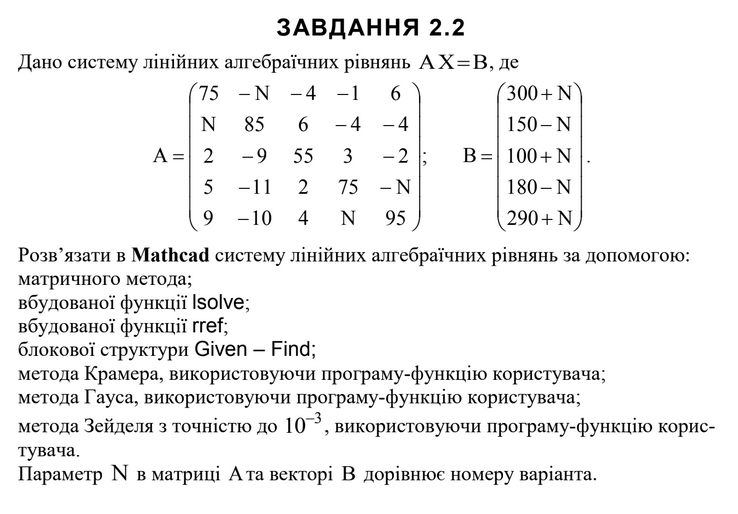

In [3]:
# Task 2.2
import numpy as np
import sympy as sp
from scipy.optimize import root

A = np.array(
    [
        [75, -1, -4, -1, 6],
        [1, 85, 6, -4, -4],
        [2, -9, 55, 3, -2],
        [5, -11, 2, 75, -1],
        [9, -10, 4, 1, 95],
    ]
)

B = np.array([301, 149, 101, 181, 291])

# Розв'язок системи рівнянь за допомогою оберненої матриці
if np.linalg.det(A) == 0:
    print("Система не має розв'язку або має безліч розв'язків.")
else:
    X = np.linalg.inv(A) @ B
    print(
        "Розв'язок системи рівнянь за допомогою оберненої матриці:", *X, sep="\n\t->| "
    )
    print("Перевірка розв'язку:")
    print("A @ X =", A @ X)
    print("B =", B)

# Аналог вбудованої функції lsolve
print(
    "\nРозв'язок системи за допомогою структури lsolve: ",
    *np.linalg.solve(A, B),
    sep="\n\t->| ",
)

# Аналог вбудованої функції rref
AB = np.column_stack((A, B))
rref_matrix, _ = sp.Matrix(AB).rref()
print(
    "\nРозв'язок системи за допомогою метода Гауса (rref): ",
    *rref_matrix[:, -1],
    sep="\n\t->| ",
)


# Розв'язок системи за допомогою методу Given-Find
def system(array, A, B):
    return A @ array - B


result = root(system, [1, 1, 1, 1, 1], args=(A, B), method="hybr")
print("\nРозв'язок системи за допомогою методу Given-Find: ", *result.x, sep="\n\t->| ")

# Розв'язок системи за допомогою метода Крамера
Xj = np.zeros(len(B))
for j in range(len(B)):
    Aj = np.copy(A)
    Aj[:, j] = B
    Xj[j] = np.linalg.det(Aj) / np.linalg.det(A)
print("\nРозв'язок системи за допомогою метода Крамера: ", *Xj, sep="\n\t->| ")

# Розв'язок системи за допомогою метода Гауса
n = len(B)
Ar = np.column_stack((A, B)).astype(float)

for i in range(n):
    for k in range(i + 1, n):
        factor = Ar[k][i] / Ar[i][i]
        Ar[k] = Ar[k] - factor * Ar[i]

X_gauss = np.zeros(n)
for i in range(n - 1, -1, -1):
    X_gauss[i] = (Ar[i][-1] - np.dot(Ar[i][i + 1 : n], X_gauss[i + 1 : n])) / Ar[i][i]
print("\nРозв'язок системи за допомогою метода Гауса: ", *X_gauss, sep="\n\t->| ")

# Розв'язок системи за допомогою метода Зейделя
C = np.zeros((n, n))
D = np.zeros(n)

for i in range(n):
    D[i] = B[i] / A[i][i]
    for j in range(n):
        if i != j:
            C[i][j] = -A[i][j] / A[i][i]

epsilon = 1e-3  # наша задана точність згідно з умовою
error = 1.0
X = np.copy(D)

while error > epsilon:
    X_old = np.copy(X)

    # Оновлюємо елементи за методом Зейделя
    for i in range(n):
        X[i] = C[i] @ X + D[i]

    error = np.max(np.abs(X - X_old))

print("\nРозв'язок системи за допомогою метода Зейделя: ", *X, sep="\n\t->| ")

Розв'язок системи рівнянь за допомогою оберненої матриці:
	->| 3.9522337995044285
	->| 1.811551131780296
	->| 1.9589465525720295
	->| 2.400262370736612
	->| 2.771677458328825
Перевірка розв'язку:
A @ X = [301. 149. 101. 181. 291.]
B = [301 149 101 181 291]

Розв'язок системи за допомогою структури lsolve: 
	->| 3.9522337995044268
	->| 1.8115511317802961
	->| 1.9589465525720293
	->| 2.4002623707366118
	->| 2.771677458328825

Розв'язок системи за допомогою метода Гауса (rref): 
	->| 9831771957/2487649379
	->| 4506504048/2487649379
	->| 4873172175/2487649379
	->| 5971011196/2487649379
	->| 6894961708/2487649379

Розв'язок системи за допомогою методу Given-Find: 
	->| 3.9522337995044277
	->| 1.8115511317802957
	->| 1.9589465525720295
	->| 2.4002623707366118
	->| 2.771677458328825

Розв'язок системи за допомогою метода Крамера: 
	->| 3.9522337995044445
	->| 1.8115511317803037
	->| 1.958946552572034
	->| 2.400262370736614
	->| 2.7716774583288224

Розв'язок системи за допомогою метода Гауса: 

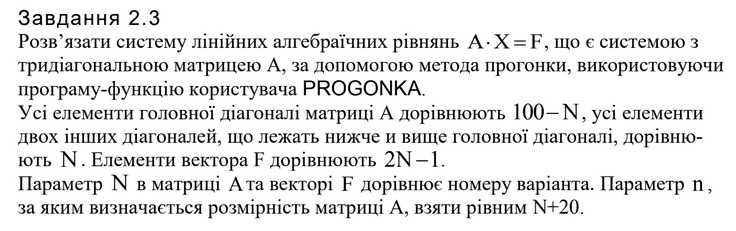

In [6]:
# Task 2.3
import numpy as np

N = 1
n = 20 + N

# Створюємо вектори для методу прогонки (тип float обов'язковий для ділення)
C = np.full(n, 100.0 * N)  # Головна діагональ
D = np.full(n, 1.0 * N)  # Нижня діагональ
B = np.full(n, 1.0 * N)  # Верхня діагональ
F = np.full(n, 2.0 * N - 1.0)  # Вектор вільних членів

alpha = np.zeros(n)
beta = np.zeros(n)

alpha[0] = B[0] / C[0]
beta[0] = F[0] / C[0]
for i in range(1, n):
    denominator = C[i] - D[i] * alpha[i - 1]
    alpha[i] = B[i] / denominator
    beta[i] = (F[i] + D[i] * beta[i - 1]) / denominator

# --- ЕТАП 2: Зворотний хід ---
X_prog = np.zeros(n)
X_prog[-1] = beta[-1]  # Останній корінь

# Йдемо у зворотному порядку від передостаннього (n-2) до нульового (-1), з кроком -1
for i in range(n - 2, -1, -1):
    X_prog[i] = alpha[i] * X_prog[i + 1] + beta[i]

print(
    "Розв'язок системи методом прогонки (перші 5 коренів):", *X_prog[:5], sep="\n\t->| "
)
print("... (останні 5 коренів):", *X_prog[-5:], sep="\n\t->| ")

Розв'язок системи методом прогонки (перші 5 коренів):
	->| 0.010102030610203571
	->| 0.010203061020357129
	->| 0.010204071425509284
	->| 0.010204081530571415
	->| 0.010204081631632143
... (останні 5 коренів):
	->| 0.010204081631632143
	->| 0.010204081530571415
	->| 0.010204071425509286
	->| 0.010203061020357129
	->| 0.010102030610203571


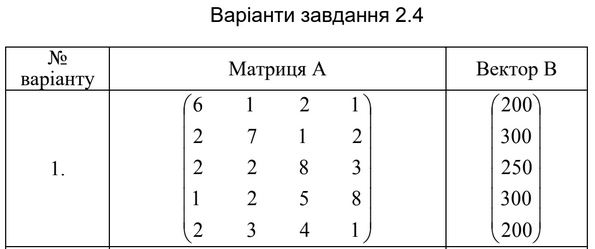

In [ ]:
# Task 2.4
import numpy as np
import sympy as sp
from scipy.optimize import least_squares

A = np.array([[6, 1, 2, 1], [2, 7, 1, 2], [2, 2, 8, 3], [1, 2, 5, 8], [2, 3, 4, 1]])

B = np.array([200, 300, 250, 300, 200])

print("=== 1. Метод найменших квадратів (ручний) ===")
AT_A = A.T @ A
AT_B = A.T @ B

if np.linalg.det(AT_A) == 0:
    print("Система не має розв'язку або має безліч розв'язків.")
else:
    X_manual = np.linalg.inv(AT_A) @ AT_B
    print("Розв'язок:", *X_manual, sep="\n\t->| ")

print("\n=== 2. Аналог функції MinErr (np.linalg.lstsq) ===")
# Це аналог вбудованих функцій для систем m > n
X_lstsq, residuals, rank, s = np.linalg.lstsq(A, B, rcond=None)
print("Розв'язок:", *X_lstsq, sep="\n\t->| ")

print("\n=== 3. Аналог блоку Given-MinErr (scipy least_squares) ===")


def system(vars, A, B):
    return A @ vars - B


# Для 4 невідомих беремо 4 нулі як початкове наближення
result = least_squares(system, [0, 0, 0, 0], args=(A, B))
print("Розв'язок:", *result.x, sep="\n\t->| ")

# === ДАЛІ ЗАСТОСОВУЄМО МЕТОДИ ДО КВАДРАТНОЇ МАТРИЦІ (AT_A) ===
A_sq = AT_A
B_sq = AT_B
n = len(B_sq)

print("\n=== 4. Метод Крамера (через нормальні рівняння) ===")
Xj = np.zeros(n)
for j in range(n):
    Aj = np.copy(A_sq)
    Aj[:, j] = B_sq
    Xj[j] = np.linalg.det(Aj) / np.linalg.det(A_sq)
print("Розв'язок:", *Xj, sep="\n\t->| ")

print("\n=== 5. Метод Гауса (через нормальні рівняння) ===")
Ar = np.column_stack((A_sq, B_sq)).astype(float)

for i in range(n):
    for k in range(i + 1, n):
        factor = Ar[k][i] / Ar[i][i]
        Ar[k] = Ar[k] - factor * Ar[i]

X_gauss = np.zeros(n)
for i in range(n - 1, -1, -1):
    X_gauss[i] = (Ar[i][-1] - np.dot(Ar[i][i + 1 : n], X_gauss[i + 1 : n])) / Ar[i][i]
print("Розв'язок:", *X_gauss, sep="\n\t->| ")

print("\n=== 6. Метод Зейделя (через нормальні рівняння) ===")
C = np.zeros((n, n))
D = np.zeros(n)

for i in range(n):
    D[i] = B_sq[i] / A_sq[i][i]
    for j in range(n):
        if i != j:
            C[i][j] = -A_sq[i][j] / A_sq[i][i]

epsilon = 1e-3
error = 1.0
X_zeidel = np.copy(D)

while error > epsilon:
    X_old = np.copy(X_zeidel)
    for i in range(n):
        X_zeidel[i] = C[i] @ X_zeidel + D[i]
    error = np.max(np.abs(X_zeidel - X_old))

print("Розв'язок:", *X_zeidel, sep="\n\t->| ")

=== 1. Метод найменших квадратів (ручний) ===
Розв'язок:
	->| 21.348034692314442
	->| 29.50220313759855
	->| 11.143443206104095
	->| 20.411836223498597

=== 2. Аналог функції MinErr (np.linalg.lstsq) ===
Розв'язок:
	->| 21.348034692314407
	->| 29.50220313759852
	->| 11.143443206104047
	->| 20.41183622349859

=== 3. Аналог блоку Given-MinErr (scipy least_squares) ===
Розв'язок:
	->| 21.348034685600858
	->| 29.502203139271003
	->| 11.143443204564683
	->| 20.41183622550461

=== 4. Метод Крамера (через нормальні рівняння) ===
Розв'язок:
	->| 21.34803469231447
	->| 29.502203137598567
	->| 11.143443206104077
	->| 20.411836223498558

=== 5. Метод Гауса (через нормальні рівняння) ===
Розв'язок:
	->| 21.348034692314442
	->| 29.50220313759854
	->| 11.143443206104077
	->| 20.411836223498597

=== 6. Метод Зейделя (через нормальні рівняння) ===
Розв'язок:
	->| 21.348590840709406
	->| 29.50267031123876
	->| 11.142462382908846
	->| 20.412310558513518


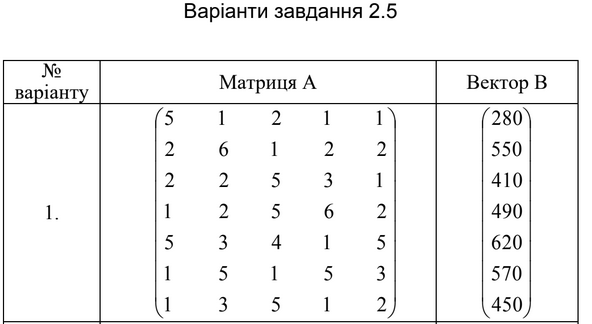

In [10]:
# Task 2.5
import numpy as np
import sympy as sp
from scipy.optimize import least_squares

A = np.array(
    [
        [5, 1, 2, 1, 1],
        [2, 6, 1, 2, 2],
        [2, 2, 5, 3, 1],
        [1, 5, 1, 5, 3],
        [5, 3, 5, 1, 2],
        [1, 5, 1, 5, 3],
        [1, 3, 5, 1, 2],
    ]
)

B = np.array([280, 550, 410, 490, 620, 570, 450])

print("=== 1. Метод найменших квадратів (ручний) ===")
AT_A = A.T @ A
AT_B = A.T @ B

if np.linalg.det(AT_A) == 0:
    print("Система не має розв'язку або має безліч розв'язків.")
else:
    X_manual = np.linalg.inv(AT_A) @ AT_B
    print("Розв'язок:", *X_manual, sep="\n\t->| ")

print("\n=== 2. Аналог функції MinErr (np.linalg.lstsq) ===")
# Це аналог вбудованих функцій для систем m > n
X_lstsq, residuals, rank, s = np.linalg.lstsq(A, B, rcond=None)
print("Розв'язок:", *X_lstsq, sep="\n\t->| ")

print("\n=== 3. Аналог блоку Given-MinErr (scipy least_squares) ===")


def system(vars, A, B):
    return A @ vars - B


# Для 5 невідомих беремо 5 нулі як початкове наближення
result = least_squares(system, [0, 0, 0, 0, 0], args=(A, B))
print("Розв'язок:", *result.x, sep="\n\t->| ")

# === ДАЛІ ЗАСТОСОВУЄМО МЕТОДИ ДО КВАДРАТНОЇ МАТРИЦІ (AT_A) ===
A_sq = AT_A
B_sq = AT_B
n = len(B_sq)

print("\n=== 4. Метод Крамера (через нормальні рівняння) ===")
Xj = np.zeros(n)
for j in range(n):
    Aj = np.copy(A_sq)
    Aj[:, j] = B_sq
    Xj[j] = np.linalg.det(Aj) / np.linalg.det(A_sq)
print("Розв'язок:", *Xj, sep="\n\t->| ")

print("\n=== 5. Метод Гауса (через нормальні рівняння) ===")
Ar = np.column_stack((A_sq, B_sq)).astype(float)

for i in range(n):
    for k in range(i + 1, n):
        factor = Ar[k][i] / Ar[i][i]
        Ar[k] = Ar[k] - factor * Ar[i]

X_gauss = np.zeros(n)
for i in range(n - 1, -1, -1):
    X_gauss[i] = (Ar[i][-1] - np.dot(Ar[i][i + 1 : n], X_gauss[i + 1 : n])) / Ar[i][i]
print("Розв'язок:", *X_gauss, sep="\n\t->| ")

print("\n=== 6. Метод Зейделя (через нормальні рівняння) ===")
C = np.zeros((n, n))
D = np.zeros(n)

for i in range(n):
    D[i] = B_sq[i] / A_sq[i][i]
    for j in range(n):
        if i != j:
            C[i][j] = -A_sq[i][j] / A_sq[i][i]

epsilon = 1e-3
error = 1.0
X_zeidel = np.copy(D)

while error > epsilon:
    X_old = np.copy(X_zeidel)
    for i in range(n):
        X_zeidel[i] = C[i] @ X_zeidel + D[i]
    error = np.max(np.abs(X_zeidel - X_old))

print("Розв'язок:", *X_zeidel, sep="\n\t->| ")

=== 1. Метод найменших квадратів (ручний) ===
Розв'язок:
	->| 26.576433121018773
	->| 62.272677355589785
	->| 34.60136173951251
	->| 5.902701515484444
	->| 41.586865802766724

=== 2. Аналог функції MinErr (np.linalg.lstsq) ===
Розв'язок:
	->| 26.576433121019143
	->| 62.27267735558979
	->| 34.60136173951244
	->| 5.902701515484307
	->| 41.5868658027673

=== 3. Аналог блоку Given-MinErr (scipy least_squares) ===
Розв'язок:
	->| 26.576432912944508
	->| 62.27267806560301
	->| 34.60136188793364
	->| 5.902700931475204
	->| 41.58686529914361

=== 4. Метод Крамера (через нормальні рівняння) ===
Розв'язок:
	->| 26.576433121019367
	->| 62.272677355590126
	->| 34.60136173951247
	->| 5.902701515484326
	->| 41.58686580276756

=== 5. Метод Гауса (через нормальні рівняння) ===
Розв'язок:
	->| 26.57643312101911
	->| 62.27267735558971
	->| 34.6013617395124
	->| 5.9027015154842415
	->| 41.58686580276751

=== 6. Метод Зейделя (через нормальні рівняння) ===
Розв'язок:
	->| 26.57604847841688
	->| 62.2678372

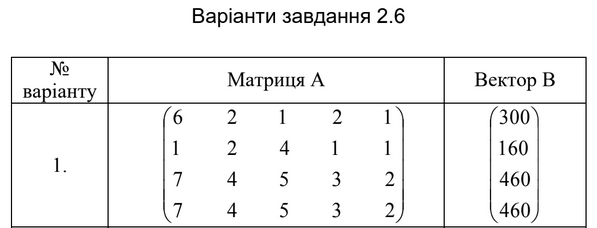

In [ ]:
# Task 2.6
import numpy as np
import sympy as sp
from scipy.optimize import least_squares

A = np.array(
    [
        [6, 2, 1, 2, 1],
        [1, 2, 4, 1, 1],
        [7, 4, 5, 3, 2],
        [7, 4, 5, 3, 2],
    ]
)
B = np.array([300, 160, 460, 460])

print("=== 1. Метод найменших квадратів (ручний) ===")
AT_A = A.T @ A
AT_B = A.T @ B
if np.linalg.matrix_rank(AT_A) < AT_A.shape[0]:
    # AT_A вироджена — використовуємо псевдообернену матрицю
    X_manual = np.linalg.pinv(AT_A) @ AT_B
    print("(AT_A вироджена — використано псевдообернену матрицю)")
else:
    X_manual = np.linalg.inv(AT_A) @ AT_B
print("Розв'язок:", *X_manual, sep="\n\t->| ")

print("\n=== 2. Аналог функції MinErr (np.linalg.lstsq) ===")
X_lstsq, residuals, rank, s = np.linalg.lstsq(A, B, rcond=None)
print("Розв'язок:", *X_lstsq, sep="\n\t->| ")

print("\n=== 3. Аналог блоку Given-MinErr (scipy least_squares) ===")


def system(vars, A, B):
    return A @ vars - B


result = least_squares(system, X_lstsq, args=(A, B))  # початкове наближення = lstsq
print("Розв'язок:", *result.x, sep="\n\t->| ")

# === ДАЛІ ЗАСТОСОВУЄМО МЕТОДИ ДО КВАДРАТНОЇ МАТРИЦІ (AT_A) ===
# Оскільки AT_A вироджена, додаємо регуляризацію (ridge)
lambda_reg = 1e-6
A_sq = AT_A + lambda_reg * np.eye(AT_A.shape[0])
B_sq = AT_B
n = len(B_sq)

print("\n=== 4. Метод Крамера (через нормальні рівняння + регуляризація) ===")
det_A_sq = np.linalg.det(A_sq)
if abs(det_A_sq) < 1e-10:
    print("Матриця вироджена навіть після регуляризації.")
else:
    Xj = np.zeros(n)
    for j in range(n):
        Aj = np.copy(A_sq)
        Aj[:, j] = B_sq
        Xj[j] = np.linalg.det(Aj) / det_A_sq
    print("Розв'язок:", *Xj, sep="\n\t->| ")

print("\n=== 5. Метод Гауса (через нормальні рівняння + регуляризація) ===")
Ar = np.column_stack((A_sq, B_sq)).astype(float)
for i in range(n):
    for k in range(i + 1, n):
        factor = Ar[k][i] / Ar[i][i]
        Ar[k] = Ar[k] - factor * Ar[i]

X_gauss = np.zeros(n)
for i in range(n - 1, -1, -1):
    X_gauss[i] = (Ar[i][-1] - np.dot(Ar[i][i + 1 : n], X_gauss[i + 1 : n])) / Ar[i][i]
print("Розв'язок:", *X_gauss, sep="\n\t->| ")

print("\n=== 6. Метод Зейделя (через нормальні рівняння + регуляризація) ===")
C = np.zeros((n, n))
D = np.zeros(n)
for i in range(n):
    D[i] = B_sq[i] / A_sq[i][i]
    for j in range(n):
        if i != j:
            C[i][j] = -A_sq[i][j] / A_sq[i][i]

epsilon = 1e-3
error = 1.0
X_zeidel = np.copy(D)
while error > epsilon:
    X_old = np.copy(X_zeidel)
    for i in range(n):
        X_zeidel[i] = C[i] @ X_zeidel + D[i]
    error = np.max(np.abs(X_zeidel - X_old))
print("Розв'язок:", *X_zeidel, sep="\n\t->| ")

=== 1. Метод найменших квадратів (ручний) ===
(AT_A вироджена — використано псевдообернену матрицю)
Розв'язок:
	->| 35.552665799739934
	->| 16.74902470741221
	->| 17.191157347204115
	->| 13.81014304291288
	->| 8.374512353706098

=== 2. Аналог функції MinErr (np.linalg.lstsq) ===
Розв'язок:
	->| 35.55266579973995
	->| 16.74902470741223
	->| 17.191157347204157
	->| 13.81014304291288
	->| 8.374512353706114

=== 3. Аналог блоку Given-MinErr (scipy least_squares) ===
Розв'язок:
	->| 35.55266579973995
	->| 16.74902470741223
	->| 17.191157347204157
	->| 13.81014304291288
	->| 8.374512353706114

=== 4. Метод Крамера (через нормальні рівняння + регуляризація) ===
Матриця вироджена навіть після регуляризації.

=== 5. Метод Гауса (через нормальні рівняння + регуляризація) ===
Розв'язок:
	->| 35.55266554022479
	->| 16.749024623765212
	->| 17.191157646595776
	->| 13.810142741914461
	->| 8.37451229487047

=== 6. Метод Зейделя (через нормальні рівняння + регуляризація) ===
Розв'язок:
	->| -83.1867172